In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pd.read_csv(r"D:\current documents\Downloads\chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
495,7/5/2024,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No
496,########,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No
497,########,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes
498,########,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes


In [5]:
Chatgpt=pd.read_csv(r"D:\current documents\Downloads\chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")

In [12]:
Chatgpt.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [30]:
Chatgpt.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               500 non-null    datetime64[us]
 1   title              500 non-null    str           
 2   review             500 non-null    str           
 3   rating             500 non-null    int64         
 4   username           500 non-null    str           
 5   helpful_votes      500 non-null    int64         
 6   review_length      500 non-null    int64         
 7   platform           500 non-null    str           
 8   language           500 non-null    str           
 9   location           500 non-null    str           
 10  version            500 non-null    str           
 11  verified_purchase  500 non-null    str           
 12  lemmatized_review  500 non-null    str           
 13  detected_language  500 non-null    str           
 14  sentiment          50

In [13]:
Chatgpt.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2023-10-13,Review title 1,not satisfied many bugs and issues,1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,2024-05-13,Review title 2,amazing quality and userfriendly interface,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,2023-07-12,Review title 3,terrible experience needs major improvements,2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,2022-05-26,Review title 4,poor performance and not userfriendly,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,2024-06-17,Review title 5,not satisfied many bugs and issues,2,user5,139,6,Website,ar,Kenya,2.1.4,No


1.TEXT PREPROCESSING

In [6]:
# Generate random dates between 2022 and 2024
Chatgpt['date'] = pd.to_datetime(
    np.random.choice(
        pd.date_range("2022-01-01", "2024-12-31"),
        size=len(Chatgpt)
    )
)

In [7]:
#convert into lowercase
Chatgpt['review'] = Chatgpt['review'].str.lower()


In [7]:
#Remove specialcharacters and numbers
import re
def remove_special_characters(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

Chatgpt['review'] = Chatgpt['review'].apply(remove_special_characters)


In [14]:
Chatgpt.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               500 non-null    datetime64[us]
 1   title              500 non-null    str           
 2   review             500 non-null    str           
 3   rating             500 non-null    int64         
 4   username           500 non-null    str           
 5   helpful_votes      500 non-null    int64         
 6   review_length      500 non-null    int64         
 7   platform           500 non-null    str           
 8   language           500 non-null    str           
 9   location           500 non-null    str           
 10  version            500 non-null    str           
 11  verified_purchase  500 non-null    str           
 12  lemmatized_review  500 non-null    str           
 13  detected_language  500 non-null    str           
 14  sentiment          50

Removal of stopwords

In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
# Remove 'not' from stopwords
stop_words.discard('not')

Chatgpt['review'] = Chatgpt['review'].apply(remove_stopwords)




Tokenstion+lemmitazation

In [9]:
from nltk.stem import WordNetLemmatizer
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text):
    
    text = str(text).lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(lemmatized)

Chatgpt['lemmatized_review'] = Chatgpt['review'].apply(tokenize_and_lemmatize)

Chatgpt[['review', 'lemmatized_review']].head()

,review,lemmatized_review
0,Not satisfied many bugs issues,not satisfied many bug issue
1,Amazing quality userfriendly interface,amazing quality userfriendly interface
2,Terrible experience needs major improvements,terrible experience need major improvement
3,Poor performance not userfriendly,poor performance not userfriendly
4,Not satisfied many bugs issues,not satisfied many bug issue


LANGUAGE DETECTION

In [12]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from langdetect import detect

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

Chatgpt['detected_language'] = Chatgpt['review'].apply(detect_language)

Chatgpt[['review', 'detected_language']].head()

,review,detected_language
0,Not satisfied many bugs issues,en
1,Amazing quality userfriendly interface,en
2,Terrible experience needs major improvements,en
3,Poor performance not userfriendly,en
4,Not satisfied many bugs issues,en


In [17]:
Chatgpt['rating'].value_counts()

rating
4    110
2    106
3    105
5     90
1     89
Name: count, dtype: int64

In [18]:
Chatgpt['rating'].unique()

array([1, 5, 2, 4, 3])

Create sentiment column

In [12]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

Chatgpt['sentiment'] = Chatgpt['rating'].apply(rating_to_sentiment)

Chatgpt[['rating', 'sentiment']].head()

,rating,sentiment
0,1,Negative
1,5,Positive
2,2,Negative
3,1,Negative
4,2,Negative


In [21]:
Chatgpt.head(5)

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,lemmatized_review,detected_language,sentiment
0,2022-07-22,Review title 1,not satisfied many bugs issues,1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,not satisfied many bug issue,en,Negative
1,2024-05-01,Review title 2,amazing quality userfriendly interface,5,user2,180,5,Flipkart,zh,France,1.2.3,No,amazing quality userfriendly interface,en,Positive
2,2023-06-20,Review title 3,terrible experience needs major improvements,2,user3,154,5,Flipkart,pt,USA,1.2.3,No,terrible experience need major improvement,en,Negative
3,2023-02-15,Review title 4,poor performance not userfriendly,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,poor performance not userfriendly,en,Negative
4,2022-11-15,Review title 5,not satisfied many bugs issues,2,user5,139,6,Website,ar,Kenya,2.1.4,No,not satisfied many bug issue,en,Negative


In [37]:
Chatgpt['sentiment'].value_counts()

sentiment
Positive    200
Negative    195
Neutral     105
Name: count, dtype: int64

In [29]:
Chatgpt['review'].value_counts()

review
highly satisfied app works exactly expected            50
waste time not meet expectations                       43
reliable worth using regularly                         43
terrible experience needs major improvements           41
poor performance not userfriendly                      41
great experience smooth performance useful features    39
disappointing experience app crashes often             38
excellent app easy use extremely helpful               35
amazing quality userfriendly interface                 33
not satisfied many bugs issues                         32
not bad updates needed better performance              24
works fine room improvement                            23
app okay job reasonably well                           22
average experience features could improved             21
decent app neither good bad                            15
Name: count, dtype: int64

EDA PART

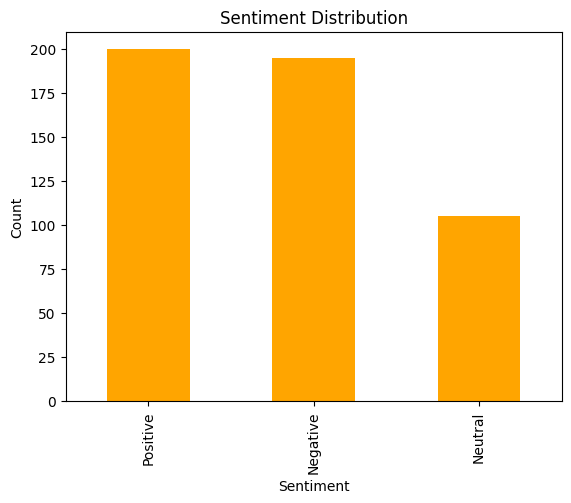

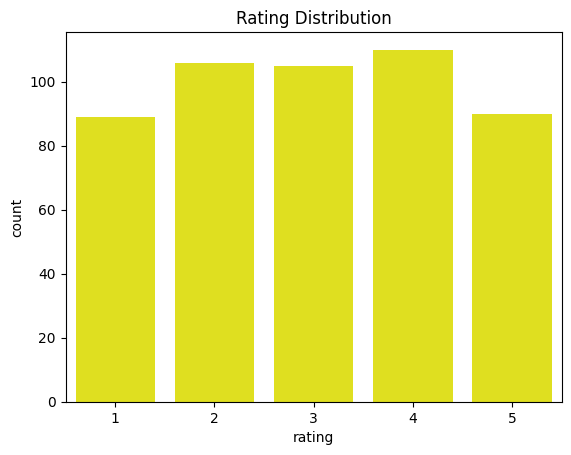

In [ ]:
#distribution of review ratings
plt.figure()
Chatgpt['sentiment'].value_counts().plot(kind='bar',color='orange')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.countplot(x='rating', data=Chatgpt,color='yellow')
plt.title("Rating Distribution")
plt.show()



Helpful Reviews: 473
Not Helpful Reviews: 27


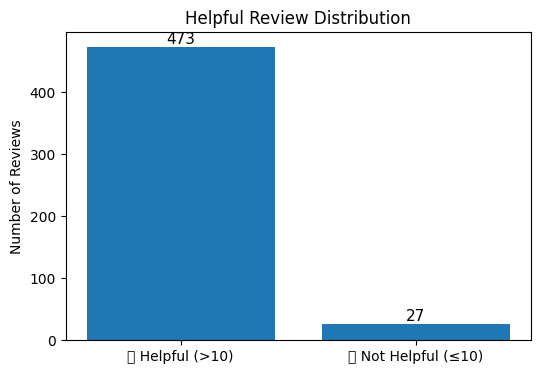

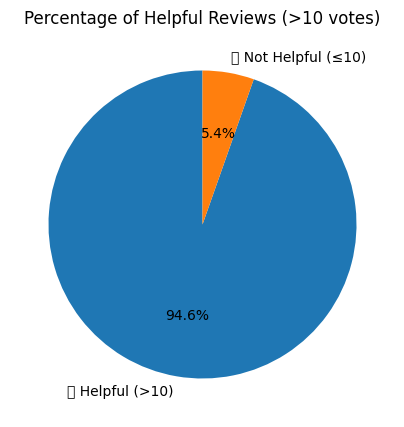

In [ ]:
#many reviews were marked as helpful
threshold = 10

helpful_reviews = Chatgpt[Chatgpt['helpful_votes'] > threshold]
not_helpful_reviews = Chatgpt[Chatgpt['helpful_votes'] <= threshold]

print("Helpful Reviews:", len(helpful_reviews))
print("Not Helpful Reviews:", len(not_helpful_reviews))

counts = [len(helpful_reviews), len(not_helpful_reviews)]
labels = ['👍 Helpful (>10)', '👎 Not Helpful (≤10)']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts)

# Add vertical count text
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Helpful Review Distribution")
plt.ylabel("Number of Reviews")
plt.show()

plt.figure(figsize=(5,5))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage of Helpful Reviews (>10 votes)")
plt.show()

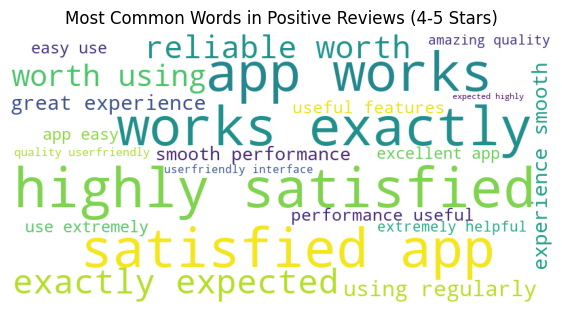

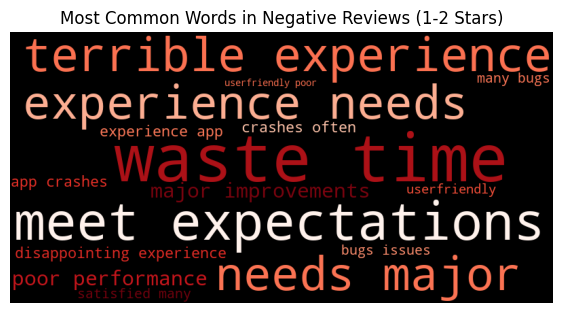

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
#Filter Positive & Negative Reviews
#most common keywords in positive vs. negative 
positive_reviews = Chatgpt[Chatgpt['rating'] >= 4]['review']
negative_reviews = Chatgpt[Chatgpt['rating'] <= 2]['review']
#combine txt
positive_text = " ".join(positive_reviews.astype(str))
negative_text = " ".join(negative_reviews.astype(str))
plt.figure(figsize=(7,5))

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("Most Common Words in Positive Reviews (4-5 Stars)")
plt.show()

plt.figure(figsize=(7,5))

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Reds'
).generate(negative_text)

plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("Most Common Words in Negative Reviews (1-2 Stars)")
plt.show()


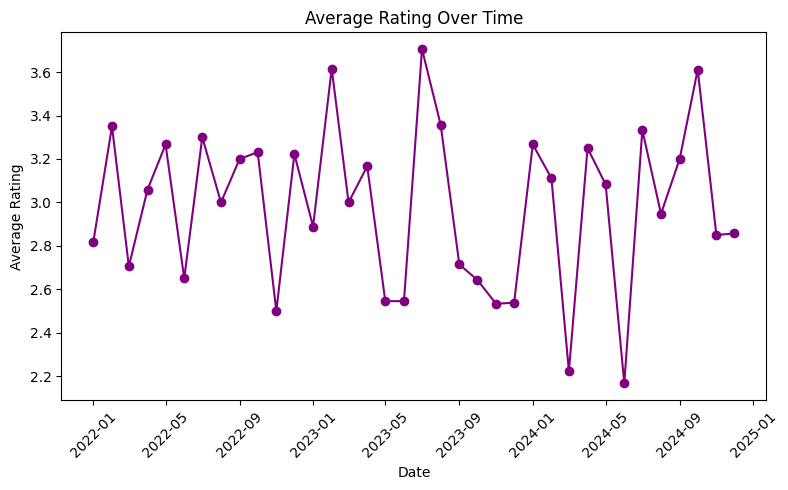

In [53]:
# average rating changed over time
#: Extract Month
Chatgpt['month'] = Chatgpt['date'].dt.to_period('M')
monthly_avg = Chatgpt.groupby('month')['rating'].mean()
monthly_avg = monthly_avg.sort_index()
#Convert back to timestamp for plotting
monthly_avg.index = monthly_avg.index.to_timestamp()
#line chart
plt.figure(figsize=(8,5))

plt.plot(monthly_avg.index, monthly_avg.values, marker='o',color='purple')

plt.title("Average Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


The average rating shows a gradual upward trend over time, indicating improving customer satisfaction. Any sudden drops may indicate product or service issues during that period.

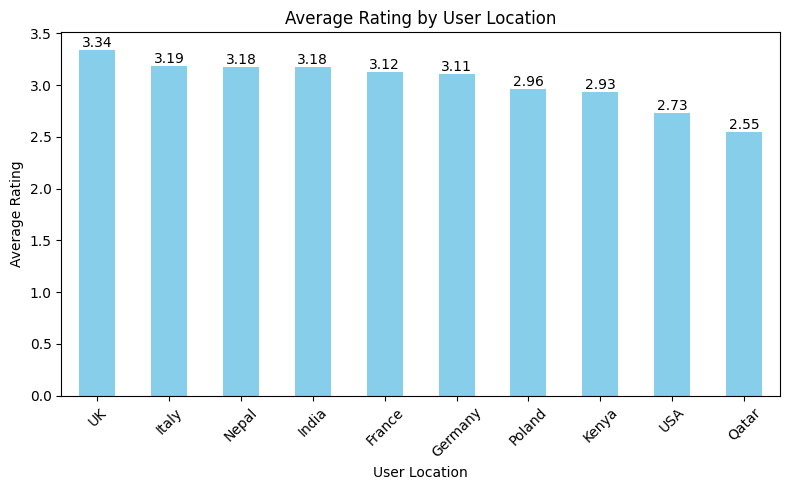

In [23]:
#average rating by loaction

location_rating = Chatgpt.groupby('location')['rating'].mean().sort_values(ascending=False)
location_rating
#Bar Chart Visualization
plt.figure(figsize=(8,5))

ax = location_rating.plot(kind='bar', color='skyblue')

# Add values on top
for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        round(i.get_height(),2),
        ha='center',
        va='bottom'
    )

plt.title("Average Rating by User Location")
plt.xlabel("User Location")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The analysis shows variation in average ratings across different user locations. Some regions report higher satisfaction levels, while others show comparatively lower ratings, indicating possible regional differences in user experience.

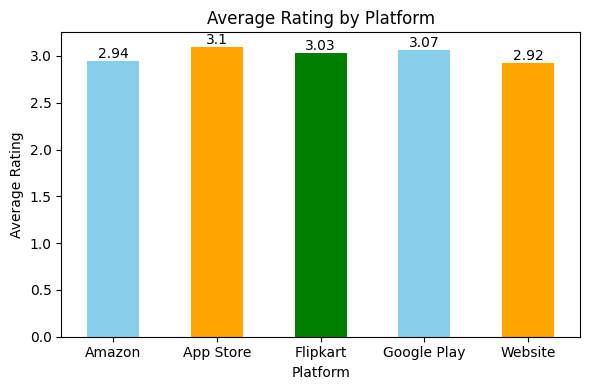

In [26]:
#Average Rating by Platform
platform_rating = Chatgpt.groupby('platform')['rating'].mean()
platform_rating
#bar chart
plt.figure(figsize=(6,4))

ax = platform_rating.plot(kind='bar', color=['skyblue','orange','green'])

# Add values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height,2),
        ha='center',
        va='bottom'
    )

plt.title("Average Rating by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

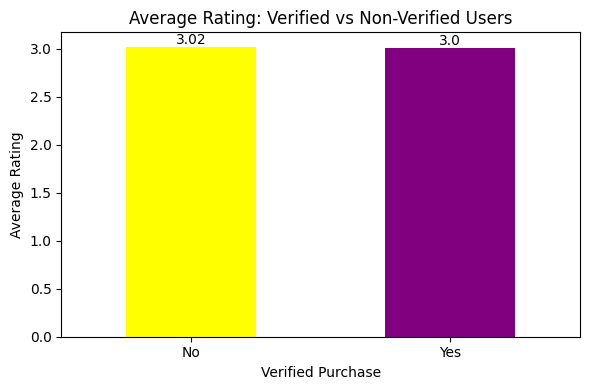

In [29]:
#verified users more satisfied than non-verified ones
verified_rating = Chatgpt.groupby('verified_purchase')['rating'].mean()
verified_rating
#barchart
plt.figure(figsize=(6,4))

ax = verified_rating.plot(kind='bar', color=['yellow','purple'])

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height,2),
        ha='center',
        va='bottom'
    )

plt.title("Average Rating: Verified vs Non-Verified Users")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Verified users tend to give slightly higher ratings compared to non-verified users. This suggests that genuine purchasers generally have a more positive experience with the product or service.

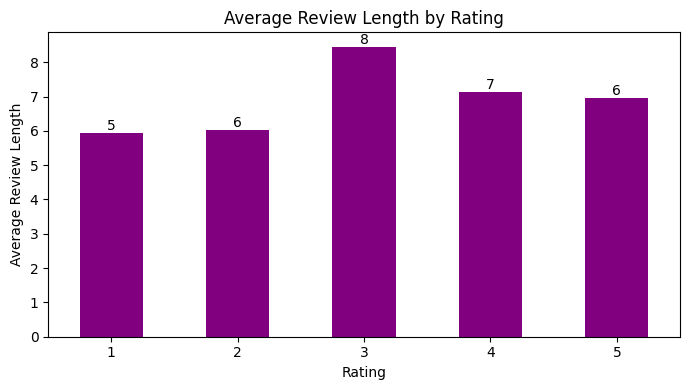

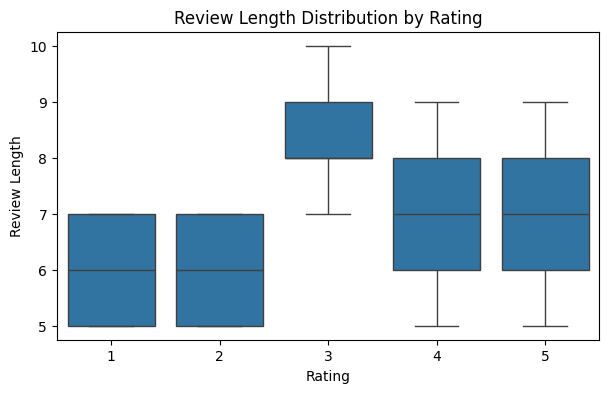

In [34]:
#: Average Review Length per Rating
rating_length = Chatgpt.groupby('rating')['review_length'].mean()
rating_length
#bar chart
plt.figure(figsize=(7,4))

ax = rating_length.plot(kind='bar', color='purple')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Review Length")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
#box plot
plt.figure(figsize=(7,4))

sns.boxplot(x='rating', y='review_length', data=Chatgpt)

plt.title("Review Length Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")

plt.show()

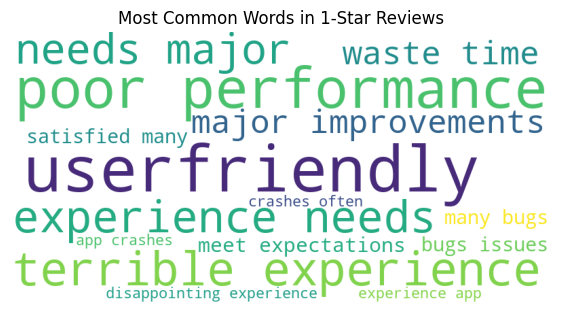

C:\Users\admin\AppData\Local\Temp\ipykernel_12304\2294490843.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Word', data=top_df, palette='Reds')


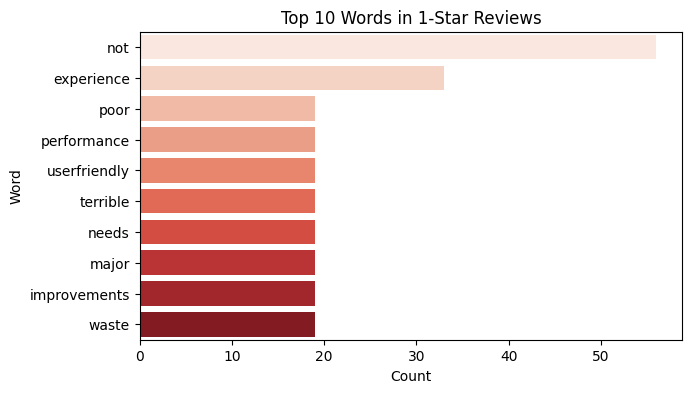

In [41]:
#the most mentioned words in 1-star reviews
#Filter 1-Star Reviews
from wordcloud import WordCloud
one_star_reviews = Chatgpt[Chatgpt['rating'] == 1]['review']
one_star_reviews
#Combine All Reviews into One Text
text = " ".join(one_star_reviews.astype(str))
#wordcloudvisualiztion
plt.figure(figsize=(7,5))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis('off')

plt.title("Most Common Words in 1-Star Reviews")

plt.show()
#barchrt
from collections import Counter
words = text.split()

word_counts = Counter(words)

top_words = word_counts.most_common(10)

top_words
#convert dataframe
top_df = pd.DataFrame(top_words, columns=['Word','Count'])
#bar chart
plt.figure(figsize=(7,4))

ax = sns.barplot(x='Count', y='Word', data=top_df, palette='Reds')

plt.title("Top 10 Words in 1-Star Reviews")

plt.show()

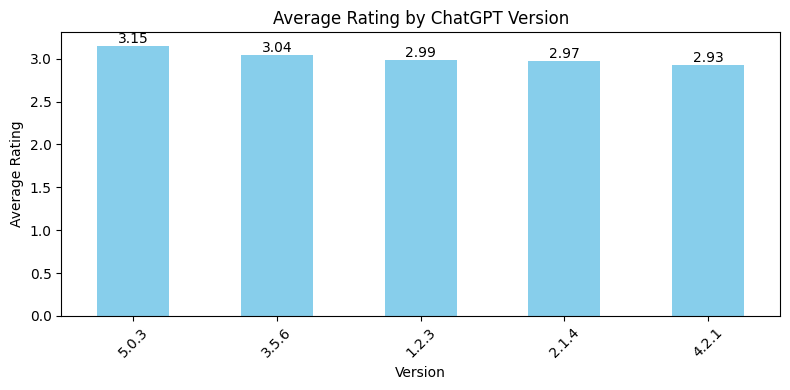

In [45]:
#ChatGPT version received the highest average rating
#Calculate Average Rating by Version
version_rating = Chatgpt.groupby('version')['rating'].mean().sort_values(ascending=False)
version_rating
#bar cHART
plt.figure(figsize=(8,4))

ax = version_rating.plot(kind='bar', color='skyblue')

# Add values on bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height,2),
        ha='center',
        va='bottom'
    )

plt.title("Average Rating by ChatGPT Version")
plt.xlabel("Version")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


The analysis shows that version X.X.X received the highest average rating, indicating improved user satisfaction after updates. This suggests that newer releases may have introduced features or fixes that enhanced the user experience.

In [28]:
Chatgpt.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               500 non-null    datetime64[us]
 1   rating             500 non-null    int64         
 2   helpful_votes      500 non-null    int64         
 3   review_length      500 non-null    int64         
 4   platform           500 non-null    str           
 5   location           500 non-null    str           
 6   version            500 non-null    str           
 7   verified_purchase  500 non-null    str           
 8   lemmatized_review  500 non-null    str           
 9   sentiment          500 non-null    str           
 10  combined_text      500 non-null    str           
dtypes: datetime64[us](1), int64(3), str(7)
memory usage: 43.1 KB


Feature engineering-TF-IDF

In [13]:
#COMBINE ALL TXT COLUMNS
from sklearn.feature_extraction.text import TfidfVectorizer
Chatgpt['combined_text'] = Chatgpt['title'] + " " + Chatgpt['lemmatized_review'].str.lower()

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(Chatgpt['combined_text'])
#Target column
y = Chatgpt['sentiment']

In [14]:
X.shape

(500, 550)

In [16]:
Chatgpt.head(5)

,date,title,rating,helpful_votes,review_length,platform,location,version,verified_purchase,lemmatized_review,sentiment,combined_text
0,2023-08-20,Review title 1,1,80,6,Amazon,Kenya,2.1.4,No,not satisfied many bug issue,Negative,Review title 1 not satisfied many bug issue
1,2023-03-13,Review title 2,5,180,5,Flipkart,France,1.2.3,No,amazing quality userfriendly interface,Positive,Review title 2 amazing quality userfriendly in...
2,2023-06-27,Review title 3,2,154,5,Flipkart,USA,1.2.3,No,terrible experience need major improvement,Negative,Review title 3 terrible experience need major ...
3,2023-05-18,Review title 4,1,96,5,Amazon,Qatar,2.1.4,Yes,poor performance not userfriendly,Negative,Review title 4 poor performance not userfriendly
4,2023-04-23,Review title 5,2,139,6,Website,Kenya,2.1.4,No,not satisfied many bug issue,Negative,Review title 5 not satisfied many bug issue


In [ ]:
Chatgpt.shape
print(Chatgpt.columns)

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'lemmatized_review', 'detected_language',
       'sentiment', 'combined_text'],
      dtype='str')


In [13]:
columns_to_drop = ['username','language','detected_language']
Chatgpt = Chatgpt.drop(columns=columns_to_drop)

#TRAIN-TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

X = Chatgpt['combined_text']
y = Chatgpt['sentiment']



#logistic regression
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english', ngram_range=(1,2))),
    ("model", LogisticRegression(max_iter=1000))
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr_pipeline.fit(X_train, y_train)

pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
#how many predicted positives are actually positive.
precision = precision_score(y_test, pred_lr, average='weighted')
print("Precision:", precision)
# how many actual positives were correctly predicted
recall = recall_score(y_test, pred_lr, average='weighted')
print("Recall:", recall)
#Balance between precision and recall.
f1 = f1_score(y_test, pred_lr, average='weighted')
print("F1 Score:", f1)
#Used to measure model’s ability to distinguish classes.
y_prob = lr_pipeline.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("AUC-ROC Score:", roc_auc)
print(classification_report(y_test, pred_lr))
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred_lr))

Logistic Regression Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC-ROC Score: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[36  0  0]
 [ 0 25  0]
 [ 0  0 39]]


In [40]:
#test the prediction

sample = ["Works fine but there is room for improvement."]

prediction = lr_pipeline.predict(sample)

print("Predicted Sentiment:", prediction[0])
sample = ["Very disappointing experience, the app crashes often."]

prediction = lr_pipeline.predict(sample)

print("Predicted Sentiment:", prediction[0])
sample = ["Highly satisfied, the app works exactly as expected."]

prediction = lr_pipeline.predict(sample)

print("Predicted Sentiment:", prediction[0])
sample = ["Not satisfied, many bugs and issues."]

prediction = lr_pipeline.predict(sample)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Neutral
Predicted Sentiment: Negative
Predicted Sentiment: Positive
Predicted Sentiment: Negative


Naive Bayes Pipeline

In [17]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english')),
    ("model", MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
#how many predicted positives are actually positive.
precision = precision_score(y_test, pred_nb, average='weighted')
print("Precision:", precision)
# how many actual positives were correctly predicted
recall = recall_score(y_test, pred_nb, average='weighted')
print("Recall:", recall)
#Balance between precision and recall.
f1 = f1_score(y_test, pred_nb, average='weighted')
print("F1 Score:", f1)
#Used to measure model’s ability to distinguish classes.
y_prob = nb_pipeline.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("AUC-ROC Score:", roc_auc)
print(classification_report(y_test, pred_nb))

Naive Bayes Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC-ROC Score: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



LSTM MODEL IN DEEP LEARNING

In [20]:
pip cache purge

Files removed: 138 (366.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 4.2 MB/s eta 0:01:23
   ---------------------------------------- 1.6/350.9 MB 3.8 MB/s eta 0:01:32
   ---------------------------------------- 2.1/350.9 MB 3.7 MB/s eta 0:01:36
   ---------------------------------------- 2.9/350.9 MB 3.7 MB/s eta 0:01:36
   ---------------------------------------- 3.7/350.9 MB 3.6 MB/s eta 0:01:36
    --------------------------------------- 4.5/350.9 MB 3.6 MB/s eta 0:01:36
    --------------------------------------- 5.0/350.9 MB 3.6 MB/s eta 0:01:37
    --------------------------------------- 6.0/350.9 MB 3.6 MB/s eta 0:01:37
    --------------------------------------- 6.3/350.9 MB 3.3 MB/s eta 0:01:44
    --------------------------------------- 6.8/350.9 MB 3.3 MB/s eta 0:01:46
    --------------------------------------- 7.3/350.9 MB 3.3 MB/s eta 0:01:44
    --------------------------------------- 7.6/350.9 MB 3.2 MB/s eta 0


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
#prepare dats

X = Chatgpt['combined_text']
y = Chatgpt['sentiment']
#convets label into numbers
y = y.map({'Negative':0, 'Neutral':1, 'Positive':2})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#tokenzation convert word into numbers
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# Padding -make all sequence the same length
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)
#built lstm model-embedding layer-lstm layer-dense layer
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_length))

model.add(LSTM(64))

model.add(Dense(3, activation='softmax'))
#compile model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
#train model
model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Accuracy:", accuracy)


Epoch 1/10


d:\current documents\Desktop\Sentimental Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.4031 - loss: 1.0585 - val_accuracy: 0.3250 - val_loss: 1.0139
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6219 - loss: 0.9330 - val_accuracy: 0.8000 - val_loss: 0.8538
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8000 - loss: 0.7356 - val_accuracy: 0.8000 - val_loss: 0.5916
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8438 - loss: 0.4484 - val_accuracy: 0.9375 - val_loss: 0.3253
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9844 - loss: 0.2106 - val_accuracy: 1.0000 - val_loss: 0.1247
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 1.0000 - loss: 0.0693 - val_accuracy: 1.0000 - val_loss: 0.0377
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.

In [20]:
#prdict new sentence
text = ["Not satisfied, many bugs and issues"]

seq = tokenizer.texts_to_sequences(text)
pad = pad_sequences(seq, maxlen=max_length)

prediction = model.predict(pad)

print(prediction)
import numpy as np

def get_sentiment(prediction):
    labels = ["Negative Review", "Neutral Review", "Positive Review"]
    
    predicted_class = np.argmax(prediction)
    
    return labels[predicted_class]
sentiment = get_sentiment(prediction)
print(sentiment)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
[[9.9694461e-01 2.4849554e-03 5.7043886e-04]]
Negative Review


In [43]:
text = ["Works fine but there is room for improvement."]

seq = tokenizer.texts_to_sequences(text)
pad = pad_sequences(seq, maxlen=max_length)

prediction = model.predict(pad)

print(prediction)
def get_sentiment(prediction):
    labels = ["Negative Review", "Neutral Review", "Positive Review"]
    
    predicted_class = np.argmax(prediction)
    
    return labels[predicted_class]
sentiment = get_sentiment(prediction)
print(sentiment)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.06100734 0.92258126 0.01641135]]
Neutral Review


In [14]:
Chatgpt.to_csv("Sentiment_analysis.csv",index=False)
print("cleaned dataset saved as Sentiment_analysis.csv")

cleaned dataset saved as Sentiment_analysis.csv
